# 02 Read Preprocessing and Reference Alignment

**Methods mapping:** read preprocessing and reference alignment.

This step summarizes the depth-QC metadata, reference FASTA/GFF files, extracted G-reference alignment, and the lengths and ambiguous-base counts of study consensus and haplotype FASTA records.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('02_read_preprocessing_and_reference_alignment', ROOT)
INPUTS = {
    "depth_qc": ROOT / "data/metadata/qualified_samples_depth200_pos90.csv",
    "reference_fasta": ROOT / "data/reference/reference.fasta",
    "annotation_gff": ROOT / "data/reference/genome_annotation.gff",
    "g_reference_alignment": ROOT / "data/reference/EPI_ISL_412866_G_4652-5617_reference_alignment.fasta",
    "AU_consensus_fasta": ROOT / "data/input/consensus/PRJNA1037681_all_consensus_extracted_4652-5617.fasta",
    "US_consensus_fasta": ROOT / "data/input/consensus/PRJNA1130896_all_consensus_extracted_4652-5617.fasta",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
}
OUTPUTS = {
    "depth_qc_summary": DATA_DIR / "depth_qc_summary_by_project.csv",
    "annotation_feature_summary": DATA_DIR / "reference_annotation_feature_summary.csv",
    "coordinate_summary": DATA_DIR / "g_gene_coordinate_summary.csv",
    "sequence_qc": DATA_DIR / "g_sequence_qc_by_project.csv",
    "depth_haplotype_table": DATA_DIR / "retained_depth_haplotype_table.csv",
    "figure_png": FIG_DIR / "FigS_depth_and_haplotype_count.png",
    "figure_pdf": FIG_DIR / "FigS_depth_and_haplotype_count.pdf",
    "figure_svg": FIG_DIR / "FigS_depth_and_haplotype_count.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,depth_qc,data/metadata/qualified_samples_depth200_pos90...,True
1,reference_fasta,data/reference/reference.fasta,True
2,annotation_gff,data/reference/genome_annotation.gff,True
3,g_reference_alignment,data/reference/EPI_ISL_412866_G_4652-5617_refe...,True
4,AU_consensus_fasta,data/input/consensus/PRJNA1037681_all_consensu...,True
5,US_consensus_fasta,data/input/consensus/PRJNA1130896_all_consensu...,True
6,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_extracted_4...,True
7,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_extracted_4...,True


### Output paths

,name,relative_path,exists
0,depth_qc_summary,data/processed_data/02_read_preprocessing_and_referen...,True
1,annotation_feature_summary,data/processed_data/02_read_preprocessing_and_referen...,True
2,coordinate_summary,data/processed_data/02_read_preprocessing_and_referen...,True
3,sequence_qc,data/processed_data/02_read_preprocessing_and_referen...,True
4,depth_haplotype_table,data/processed_data/02_read_preprocessing_and_referen...,True
5,figure_png,results/figures/02_read_preprocessing_and_refe...,True
6,figure_pdf,results/figures/02_read_preprocessing_and_refe...,True
7,figure_svg,results/figures/02_read_preprocessing_and_refe...,True


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/02_read_preprocessing_and_reference_alignment'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/02_read_preprocessing_and_reference_alignment'))

## Inspect QC Inputs

The depth table records the preprocessing threshold. FASTA QC is recalculated from the consensus and haplotype sequences included in this repository.


In [3]:
depth_qc = au.load_depth_qc(ROOT)
sequence_qc = au.fasta_qc_by_project(ROOT)
coordinate_summary = au.reference_coordinate_summary(ROOT)

depth_qc_summary = depth_qc.groupby('project', as_index=False).agg(
    samples=('SampleID', 'nunique'),
    median_mean_depth=('mean_depth', 'median'),
    median_qualified_ratio=('qualified_ratio', 'median'),
)
display(depth_qc_summary)
display(sequence_qc)
display(coordinate_summary)


,project,samples,median_mean_depth,median_qualified_ratio
0,PRJNA1037681,37,2741.080066,0.977537
1,PRJNA1130896,75,7593.937997,0.992118


,project,project_label,input_role,input_path,records,samples,min_length_nt,median_length_nt,max_length_nt,median_ambiguous_fraction,max_ambiguous_fraction
0,PRJNA1037681,Australia,study_consensus_G_FASTA,data/input/consensus/PRJNA1037681_all_consensu...,37,37,966,966.0,966,0.0,0.004141
1,PRJNA1037681,Australia,haplotype_G_FASTA,data/input/haplotypes/PRJNA1037681_extracted_4...,74,37,966,966.0,966,0.0,0.001035
2,PRJNA1130896,United States,study_consensus_G_FASTA,data/input/consensus/PRJNA1130896_all_consensu...,75,75,966,966.0,966,0.0,0.007246
3,PRJNA1130896,United States,haplotype_G_FASTA,data/input/haplotypes/PRJNA1130896_extracted_4...,144,72,966,966.0,966,0.0,0.027950


,feature,start,end,length_nt,note
0,G_extracted_window,4652,5617,966,G segment used for haplotype and consensus com...
1,HVR2_window,5249,5617,369,AA 200-322 mapped onto genome coordinates
2,GFF_remark,1,15225,15225,molecule_type=cRNA;organism=Human orthopneumov...
3,GFF_reference_record,1,15225,15225,mol_type=viral cRNA;organism=Human orthopneumo...
4,GFF_CDS,4652,5617,966,codon_start=1;db_xref=GeneID:37607642;gene=G;g...


## Generate Alignment/QC Tables

The tables below are written from the depth-QC table, reference annotation, and haplotype counts parsed from the haplotype FASTA.


In [4]:
depth_summary, feature_summary, coordinate_summary, sequence_qc, depth_hap = au.read_preprocessing_alignment_summary(ROOT, DATA_DIR)

display(depth_summary)
display(feature_summary)
display(coordinate_summary)
display(sequence_qc)
display(depth_hap.head())


,project,project_label,qualified_samples,median_mean_depth,median_median_depth,median_qualified_ratio
0,PRJNA1037681,Australia,37,2741.080066,2418.0,0.977537
1,PRJNA1130896,United States,75,7593.937997,5032.0,0.992118


,type,n_features,min_start,max_end
0,CDS,11,70,15029
1,reference_record,1,1,15225
2,remark,1,1,15225


,feature,start,end,length_nt,note
0,G_extracted_window,4652,5617,966,G segment used for haplotype and consensus com...
1,HVR2_window,5249,5617,369,AA 200-322 mapped onto genome coordinates
2,GFF_remark,1,15225,15225,molecule_type=cRNA;organism=Human orthopneumov...
3,GFF_reference_record,1,15225,15225,mol_type=viral cRNA;organism=Human orthopneumo...
4,GFF_CDS,4652,5617,966,codon_start=1;db_xref=GeneID:37607642;gene=G;g...


,project,project_label,input_role,input_path,records,samples,min_length_nt,median_length_nt,max_length_nt,median_ambiguous_fraction,max_ambiguous_fraction
0,PRJNA1037681,Australia,study_consensus_G_FASTA,data/input/consensus/PRJNA1037681_all_consensu...,37,37,966,966.0,966,0.0,0.004141
1,PRJNA1037681,Australia,haplotype_G_FASTA,data/input/haplotypes/PRJNA1037681_extracted_4...,74,37,966,966.0,966,0.0,0.001035
2,PRJNA1130896,United States,study_consensus_G_FASTA,data/input/consensus/PRJNA1130896_all_consensu...,75,75,966,966.0,966,0.0,0.007246
3,PRJNA1130896,United States,haplotype_G_FASTA,data/input/haplotypes/PRJNA1130896_extracted_4...,144,72,966,966.0,966,0.0,0.027950


,project,project_label,SampleID,n_haplotypes,mean_depth,median_depth,qualified_ratio,haplotype_count_class
0,PRJNA1037681,Australia,SRR26779971,2,2158.789491,2024.0,0.978982,2
1,PRJNA1037681,Australia,SRR26780187,2,6719.614975,6296.0,0.986732,2
2,PRJNA1037681,Australia,SRR26780146,2,6605.839869,6154.0,0.988900,2
3,PRJNA1037681,Australia,SRR26780067,2,2184.974647,1909.0,0.965189,2
4,PRJNA1037681,Australia,SRR26780213,1,2589.078358,2418.0,0.979770,1


## Figure

The figure checks whether retained samples have sufficient depth across the G segment and shows how many haplotypes were reconstructed from the haplotype FASTA per sample.


/root/autodl-tmp/rsva-g-intrahost-haplotypes/notebooks/analysis_utils.py:939: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.84, 1])


{'png': 'results/figures/02_read_preprocessing_and_reference_alignment/FigS_depth_and_haplotype_count.png',
 'pdf': 'results/figures/02_read_preprocessing_and_reference_alignment/FigS_depth_and_haplotype_count.pdf',
 'svg': 'results/figures/02_read_preprocessing_and_reference_alignment/FigS_depth_and_haplotype_count.svg'}

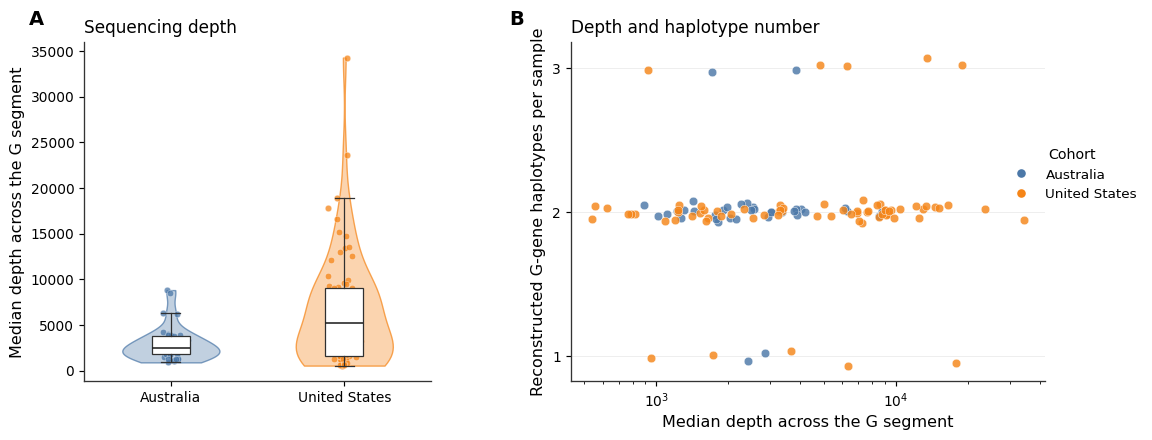

In [5]:
fig, paths = au.draw_depth_haplotype(depth_hap, FIG_DIR)
display(paths)
plt.show()
